Log klasörü bulundu:
/mnt/c/home/merve/UNI2-h/TriAlign-UDA/runs/feature_level_v2_final_20260623_123538/logs

Klasörde bulunan toplam epoch logu: 46

TriAlign_UDA için bulunan dosyalar:
  - epoch_logs_TriAlign_UDA_seed0.csv
  - epoch_logs_TriAlign_UDA_seed1.csv
  - epoch_logs_TriAlign_UDA_seed2.csv
  - epoch_logs_TriAlign_UDA_seed3.csv
  - epoch_logs_TriAlign_UDA_seed4.csv

DANN için bulunan dosyalar:
  - epoch_logs_DANN_seed0.csv
  - epoch_logs_DANN_seed1.csv
  - epoch_logs_DANN_seed2.csv
  - epoch_logs_DANN_seed3.csv
  - epoch_logs_DANN_seed4.csv


SOURCE-VALIDATION MACRO-F1 ÖZETİ

TriAlign-UDA
Epoch 1: 0.997503 ± 0.000442
Epoch 2: 0.996484 ± 0.001015
Epoch 3: 0.997496 ± 0.000372
Epoch 4: 0.997403 ± 0.000575
Epoch 5: 0.997935 ± 0.000342

DANN
Epoch 1: 0.997090 ± 0.000892
Epoch 2: 0.996165 ± 0.001281
Epoch 3: 0.996999 ± 0.001217
Epoch 4: 0.997208 ± 0.000650
Epoch 5: 0.997195 ± 0.000646


SON ÜÇ EPOCH KARARLILIK ÖZETİ

TriAlign-UDA
Epoch 3-5 ortalama değer aralığı: 0.000532
Epoch 3 ile 

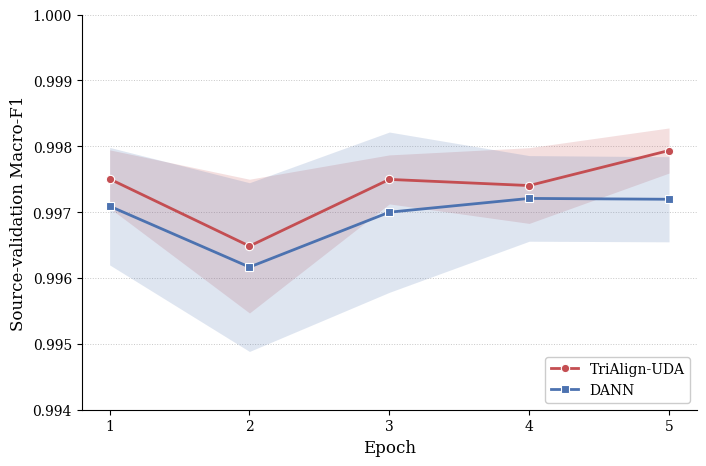

In [3]:
# ============================================================
# TriAlign-UDA ve DANN source-validation yakınsama eğrisi
# Model eğitimi yapmaz; mevcut epoch loglarını kullanır.
# ============================================================

from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 1. Dosya yolları
# ============================================================

LOG_DIR = Path(
    "/mnt/c/home/merve/UNI2-h/TriAlign-UDA/runs/"
    "feature_level_v2_final_20260623_123538/logs"
)

PLOT_DIR = LOG_DIR.parent / "plots"
PLOT_DIR.mkdir(parents=True, exist_ok=True)


# ============================================================
# 2. Klasör kontrolü
# ============================================================

if not LOG_DIR.exists():
    raise FileNotFoundError(
        f"Log klasörü bulunamadı:\n{LOG_DIR}"
    )

print(f"Log klasörü bulundu:\n{LOG_DIR}\n")

all_csv_files = sorted(LOG_DIR.glob("epoch_logs_*.csv"))

print(f"Klasörde bulunan toplam epoch logu: {len(all_csv_files)}")

if len(all_csv_files) == 0:
    raise FileNotFoundError(
        f"Log klasöründe epoch_logs_*.csv dosyası bulunamadı:\n"
        f"{LOG_DIR}"
    )


# ============================================================
# 3. Grafikte gösterilecek yöntemler
# ============================================================

METHODS = {
    "TriAlign_UDA": {
        "label": "TriAlign-UDA",
        "color": "#C44E52",
        "marker": "o",
    },
    "DANN": {
        "label": "DANN",
        "color": "#4C72B0",
        "marker": "s",
    },
}


# ============================================================
# 4. Epoch loglarını oku
# ============================================================

all_logs = []

for method in METHODS:

    method_files = sorted(
        LOG_DIR.glob(f"epoch_logs_{method}_seed*.csv")
    )

    print(f"\n{method} için bulunan dosyalar:")

    for file in method_files:
        print(f"  - {file.name}")

    if len(method_files) != 5:
        raise FileNotFoundError(
            f"\n{method} için 5 seed logu bekleniyordu, "
            f"ancak {len(method_files)} dosya bulundu.\n"
            f"Kontrol edilen klasör:\n{LOG_DIR}"
        )

    for file in method_files:

        df = pd.read_csv(file)

        required_columns = {
            "method",
            "seed",
            "epoch",
            "NCTval_macroF1",
        }

        missing_columns = required_columns.difference(df.columns)

        if missing_columns:
            raise ValueError(
                f"{file.name} dosyasında şu sütunlar eksik:\n"
                f"{sorted(missing_columns)}"
            )

        selected_columns = df[
            [
                "method",
                "seed",
                "epoch",
                "NCTval_macroF1",
            ]
        ].copy()

        all_logs.append(selected_columns)


logs = pd.concat(all_logs, ignore_index=True)


# ============================================================
# 5. Veri bütünlüğünü kontrol et
# ============================================================

expected_epochs = {1, 2, 3, 4, 5}
expected_seeds = {0, 1, 2, 3, 4}

for method in METHODS:

    method_logs = logs[logs["method"] == method].copy()

    found_epochs = set(method_logs["epoch"].unique())
    found_seeds = set(method_logs["seed"].unique())

    if found_epochs != expected_epochs:
        raise ValueError(
            f"{method} için beklenen epochlar 1-5 olmasına rağmen "
            f"şu epochlar bulundu: {sorted(found_epochs)}"
        )

    if found_seeds != expected_seeds:
        raise ValueError(
            f"{method} için beklenen seedler 0-4 olmasına rağmen "
            f"şu seedler bulundu: {sorted(found_seeds)}"
        )

    duplicated = method_logs.duplicated(
        subset=["seed", "epoch"]
    ).any()

    if duplicated:
        raise ValueError(
            f"{method} loglarında aynı seed ve epoch için "
            f"birden fazla kayıt bulundu."
        )


# ============================================================
# 6. Ortalama ve standart sapmayı hesapla
# ============================================================

summary = (
    logs.groupby(["method", "epoch"], as_index=False)
    .agg(
        macro_f1_mean=("NCTval_macroF1", "mean"),
        macro_f1_std=("NCTval_macroF1", "std"),
        n_seeds=("seed", "nunique"),
    )
)


# ============================================================
# 7. Sayısal sonuçları ekrana yazdır
# ============================================================

print("\n")
print("=" * 72)
print("SOURCE-VALIDATION MACRO-F1 ÖZETİ")
print("=" * 72)

for method, style in METHODS.items():

    method_summary = (
        summary[summary["method"] == method]
        .sort_values("epoch")
    )

    print(f"\n{style['label']}")

    for _, row in method_summary.iterrows():
        print(
            f"Epoch {int(row['epoch'])}: "
            f"{row['macro_f1_mean']:.6f} ± "
            f"{row['macro_f1_std']:.6f}"
        )


# ============================================================
# 8. Son üç epoch kararlılık değerlerini hesapla
# ============================================================

print("\n")
print("=" * 72)
print("SON ÜÇ EPOCH KARARLILIK ÖZETİ")
print("=" * 72)

for method, style in METHODS.items():

    last_three = (
        summary[
            (summary["method"] == method)
            & (summary["epoch"].isin([3, 4, 5]))
        ]
        .sort_values("epoch")
        .copy()
    )

    epoch_3 = last_three.loc[
        last_three["epoch"] == 3,
        "macro_f1_mean"
    ].iloc[0]

    epoch_5 = last_three.loc[
        last_three["epoch"] == 5,
        "macro_f1_mean"
    ].iloc[0]

    last_three_range = (
        last_three["macro_f1_mean"].max()
        - last_three["macro_f1_mean"].min()
    )

    epoch_3_to_5_difference = epoch_5 - epoch_3

    print(f"\n{style['label']}")

    print(
        f"Epoch 3-5 ortalama değer aralığı: "
        f"{last_three_range:.6f}"
    )

    print(
        f"Epoch 3 ile Epoch 5 arasındaki fark: "
        f"{epoch_3_to_5_difference:.6f}"
    )


# ============================================================
# 9. Özet değerleri CSV olarak kaydet
# ============================================================

summary_csv_path = (
    PLOT_DIR / "source_validation_convergence_summary.csv"
)

summary.to_csv(
    summary_csv_path,
    index=False,
)

print(f"\nÖzet CSV kaydedildi:\n{summary_csv_path}")


# ============================================================
# 10. Grafik biçimlendirmesi
# ============================================================

plt.rcParams.update(
    {
        "font.family": "serif",
        "font.serif": [
            "Times New Roman",
            "Times",
            "DejaVu Serif",
        ],
        "font.size": 11,
        "axes.labelsize": 12,
        "legend.fontsize": 10,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "axes.linewidth": 0.8,
    }
)

fig, ax = plt.subplots(figsize=(7.2, 4.8))


# ============================================================
# 11. Yakınsama eğrilerini çiz
# ============================================================

for method, style in METHODS.items():

    method_summary = (
        summary[summary["method"] == method]
        .sort_values("epoch")
        .copy()
    )

    epochs = method_summary["epoch"].to_numpy()
    means = method_summary["macro_f1_mean"].to_numpy()
    standard_deviations = (
        method_summary["macro_f1_std"].to_numpy()
    )

    # Beş seed üzerinden ortalama
    ax.plot(
        epochs,
        means,
        label=style["label"],
        color=style["color"],
        marker=style["marker"],
        linewidth=2.0,
        markersize=6,
        markeredgecolor="white",
        markeredgewidth=0.8,
        zorder=3,
    )

    # Ortalama ± standart sapma
    ax.fill_between(
        epochs,
        means - standard_deviations,
        means + standard_deviations,
        color=style["color"],
        alpha=0.18,
        linewidth=0,
        zorder=2,
    )


# ============================================================
# 12. Eksenler ve görünüm
# ============================================================

ax.set_xlabel("Epoch")
ax.set_ylabel("Source-validation Macro-F1")

ax.set_xticks([1, 2, 3, 4, 5])
ax.set_xlim(0.8, 5.2)

# Üst sınıra yakın değerleri ve standart sapmaları birlikte gösterir.
ax.set_ylim(0.994, 1.000)

ax.grid(
    axis="y",
    linestyle=":",
    linewidth=0.7,
    color="#B0B0B0",
    alpha=0.7,
)

ax.legend(
    loc="lower right",
    frameon=True,
    framealpha=1.0,
    edgecolor="#CCCCCC",
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.tight_layout()


# ============================================================
# 13. Grafiği kaydet
# ============================================================

png_path = (
    PLOT_DIR / "source_validation_convergence.png"
)

pdf_path = (
    PLOT_DIR / "source_validation_convergence.pdf"
)

svg_path = (
    PLOT_DIR / "source_validation_convergence.svg"
)

fig.savefig(
    png_path,
    dpi=600,
    bbox_inches="tight",
    facecolor="white",
)

fig.savefig(
    pdf_path,
    bbox_inches="tight",
    facecolor="white",
)

fig.savefig(
    svg_path,
    bbox_inches="tight",
    facecolor="white",
)


# ============================================================
# 14. Çıktıları göster
# ============================================================

print("\n")
print("=" * 72)
print("GRAFİK DOSYALARI OLUŞTURULDU")
print("=" * 72)

print(f"PNG:\n{png_path}\n")
print(f"PDF:\n{pdf_path}\n")
print(f"SVG:\n{svg_path}")

plt.show()